# **IMPORT LIBRARIES**

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:

import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **LOAD DATASET**

In [ ]:

file_path = "Delivery_Logistics_reconstructed.csv"

In [7]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir())


Current directory: c:\Users\Asus\Documents\MDS\EY intership\ETA-Delay-Prediction-Logistics\notebooks

Files in current directory:
['ETA_Delay_Prediction.ipynb']


In [9]:

df = pd.read_csv(file_path)

FileNotFoundError: [Errno 2] No such file or directory: 'Delivery_Logistics_reconstructed.csv'

In [ ]:

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully
Shape of dataset: (25000, 25)


In [ ]:
import os
print(os.getcwd())

c:\Users\Admin\Downloads


In [ ]:
print(os.listdir())

['-82.xlsx', '.git', '.ipynb_checkpoints', '.Rhistory', '02 - Conversions - All Types - Advanced (1).pdf', '02 - Conversions - All Types - Advanced (2).pdf', '02 - Conversions - All Types - Advanced.pdf', '05 - Universal Gates.pdf', '1.1.pptx', '1.2.pptx', '1.3.pptx', '1.docx', '1000069777.jpg', '1000101608.jpg', '14580510.zip', '1730697573654Instructions to Candidates_Nov 2024.doc', '1candidates.xlsx', '2024-04-06 18-15-43 - Trim.mkv', '2024-04-06 18-57-43.mkv', '2341404 ds lab-4 Q3.py', '2341404_Brochure.docx', '2341404_DV_CIA_3.docx.pdf', '2341404_DV_Cia_3.twb', '2341404_EDA (1).twb', '2341404_EDA (3).twb', '2341404_EDA.twb', '2341404_lab7.docx (1).pdf', '2341404_lab7.docx.pdf', '2341404_LAB8.twb', '2341404_R_lab-6.docx', '2341404_R_lab-6.R', '2341404_R_lab-7 (1).docx', '2341404_R_lab-7.docx', '2341406_LAB#06 (1).twb', '2341406_LAB#06 (2).twb', '2341406_LAB#06.twb', '2341406_LAB-9.sql', '2341406_Lab1-1 (1).pdf', '2341406_Lab1-1.pdf', '2341415_Cia3_report1.docx.pdf', '2341420_CIA1.do

# PART 10 — MODEL BUILDING: ALL 4 CLASSIFICATION MODELS
## (Model A — Binary | Model B — Multi-class)

## MODEL A — BINARY CLASSIFICATION (Delayed vs On-Time)
### All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# STEP 1 — TRAIN ALL 4 CLASSIFIERS (Model A: Binary)
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_A = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_A.fit(X_train_A_sc, y_train_A)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_A2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_A2.fit(X_train_A_sc, y_train_A)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_A = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_A.fit(X_train_A_sc, y_train_A)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_A = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_A.fit(X_train_A_sc, y_train_A)
print("✅ KNN done!")



🌲 Training Random Forest...
✅ Random Forest done!

📈 Training Logistic Regression...
✅ Logistic Regression done!

🌳 Training Decision Tree...
✅ Decision Tree done!

👥 Training KNN...
✅ KNN done!


In [ ]:
# ============================================================
# STEP 2 — PREDICTIONS: ALL 4 MODELS (Model A)
# ============================================================

y_pred_rf_A   = rf_A.predict(X_test_A_sc)
y_pred_lr_A2  = lr_A2.predict(X_test_A_sc)
y_pred_dt_A   = dt_A.predict(X_test_A_sc)
y_pred_knn_A  = knn_A.predict(X_test_A_sc)

y_proba_rf_A   = rf_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_lr_A2  = lr_A2.predict_proba(X_test_A_sc)[:, 1]
y_proba_dt_A   = dt_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_knn_A  = knn_A.predict_proba(X_test_A_sc)[:, 1]

print("✅ All predictions done!")


✅ All predictions done!


In [ ]:
# ============================================================
# STEP 3 — EVALUATE ALL 4 MODELS (Model A)
# ============================================================

rf_acc_A   = accuracy_score(y_test_A, y_pred_rf_A)
lr_acc_A2  = accuracy_score(y_test_A, y_pred_lr_A2)
dt_acc_A   = accuracy_score(y_test_A, y_pred_dt_A)
knn_acc_A  = accuracy_score(y_test_A, y_pred_knn_A)

rf_auc_A   = roc_auc_score(y_test_A, y_proba_rf_A)
lr_auc_A2  = roc_auc_score(y_test_A, y_proba_lr_A2)
dt_auc_A   = roc_auc_score(y_test_A, y_proba_dt_A)
knn_auc_A  = roc_auc_score(y_test_A, y_proba_knn_A)

# PR-AUC
rf_prauc_A   = average_precision_score(y_test_A, y_proba_rf_A)
lr_prauc_A2  = average_precision_score(y_test_A, y_proba_lr_A2)
dt_prauc_A   = average_precision_score(y_test_A, y_proba_dt_A)
knn_prauc_A  = average_precision_score(y_test_A, y_proba_knn_A)

print("=" * 60)
print("🌲 RANDOM FOREST — Model A")
print("=" * 60)
print(f"Accuracy : {rf_acc_A*100:.2f}% | ROC-AUC: {rf_auc_A:.4f} | PR-AUC: {rf_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_rf_A):.4f} | Precision: {precision_score(y_test_A, y_pred_rf_A):.4f} | Recall: {recall_score(y_test_A, y_pred_rf_A):.4f}")
print(classification_report(y_test_A, y_pred_rf_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("📈 LOGISTIC REGRESSION — Model A")
print("=" * 60)
print(f"Accuracy : {lr_acc_A2*100:.2f}% | ROC-AUC: {lr_auc_A2:.4f} | PR-AUC: {lr_prauc_A2:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_lr_A2):.4f} | Precision: {precision_score(y_test_A, y_pred_lr_A2):.4f} | Recall: {recall_score(y_test_A, y_pred_lr_A2):.4f}")
print(classification_report(y_test_A, y_pred_lr_A2, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("🌳 DECISION TREE — Model A")
print("=" * 60)
print(f"Accuracy : {dt_acc_A*100:.2f}% | ROC-AUC: {dt_auc_A:.4f} | PR-AUC: {dt_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_dt_A):.4f} | Precision: {precision_score(y_test_A, y_pred_dt_A):.4f} | Recall: {recall_score(y_test_A, y_pred_dt_A):.4f}")
print(classification_report(y_test_A, y_pred_dt_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("👥 KNN — Model A")
print("=" * 60)
print(f"Accuracy : {knn_acc_A*100:.2f}% | ROC-AUC: {knn_auc_A:.4f} | PR-AUC: {knn_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_knn_A):.4f} | Precision: {precision_score(y_test_A, y_pred_knn_A):.4f} | Recall: {recall_score(y_test_A, y_pred_knn_A):.4f}")
print(classification_report(y_test_A, y_pred_knn_A, target_names=['On-Time', 'Delayed']))


🌲 RANDOM FOREST — Model A
Accuracy : 88.42% | ROC-AUC: 0.9672 | PR-AUC: 0.9131
F1-Score : 0.8154 | Precision: 0.7094 | Recall: 0.9588
              precision    recall  f1-score   support

     On-Time       0.98      0.86      0.92      3666
     Delayed       0.71      0.96      0.82      1334

    accuracy                           0.88      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.88      0.89      5000

📈 LOGISTIC REGRESSION — Model A
Accuracy : 88.24% | ROC-AUC: 0.9583 | PR-AUC: 0.8743
F1-Score : 0.8058 | Precision: 0.7202 | Recall: 0.9145
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

🌳 DECISION TREE — Model A
Accuracy : 88.00% | ROC-AUC: 0.9493 | PR-AUC: 

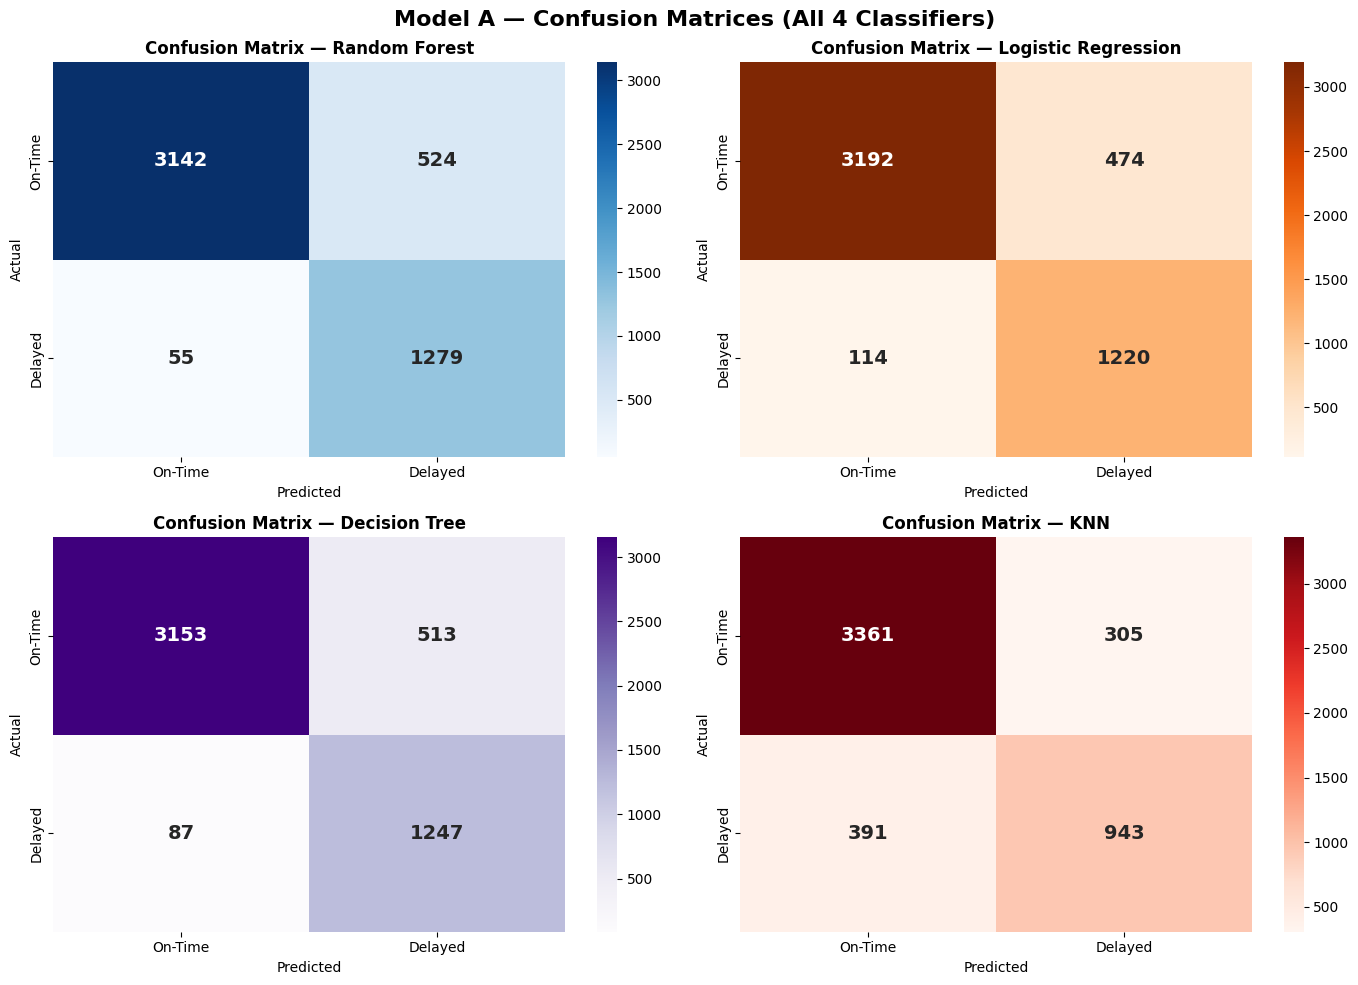

In [ ]:
# ============================================================
# STEP 4 — CONFUSION MATRICES: ALL 4 MODELS (Model A)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_A_info = [
    (y_pred_rf_A,  'Random Forest',       'Blues'),
    (y_pred_lr_A2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_A,  'Decision Tree',       'Purples'),
    (y_pred_knn_A, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_A_info):
    cm = confusion_matrix(y_test_A, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Model A — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


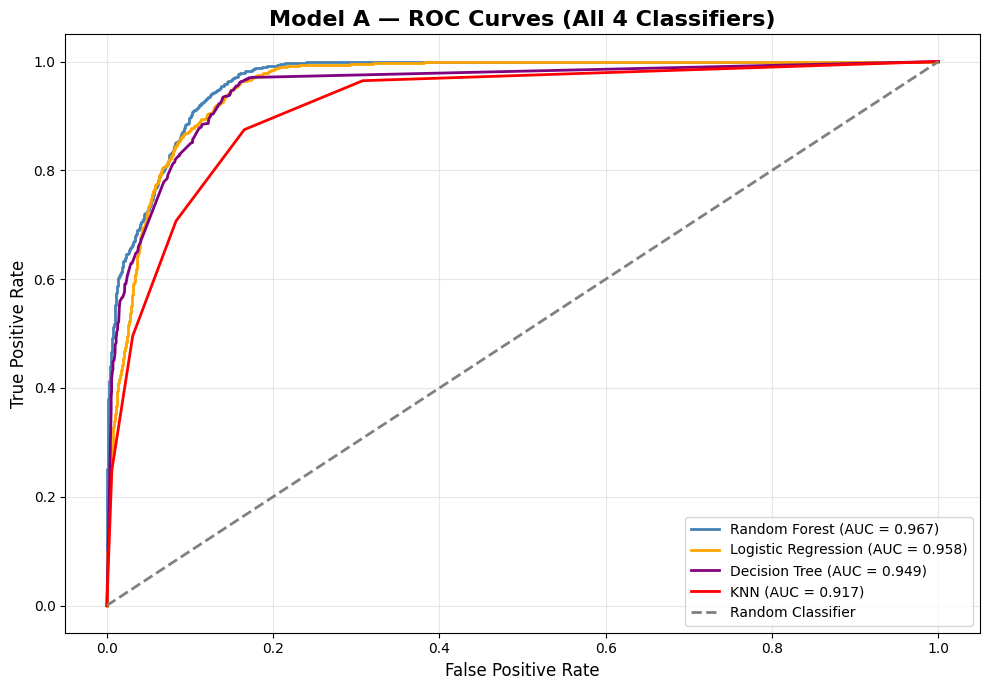

In [ ]:
# ============================================================
# STEP 5 — ROC CURVES: ALL 4 MODELS (Model A)
# ============================================================

fpr_rf_A,   tpr_rf_A,   _ = roc_curve(y_test_A, y_proba_rf_A)
fpr_lr_A2,  tpr_lr_A2,  _ = roc_curve(y_test_A, y_proba_lr_A2)
fpr_dt_A,   tpr_dt_A,   _ = roc_curve(y_test_A, y_proba_dt_A)
fpr_knn_A,  tpr_knn_A,  _ = roc_curve(y_test_A, y_proba_knn_A)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf_A,  tpr_rf_A,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc_A:.3f})')
plt.plot(fpr_lr_A2, tpr_lr_A2, color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc_A2:.3f})')
plt.plot(fpr_dt_A,  tpr_dt_A,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc_A:.3f})')
plt.plot(fpr_knn_A, tpr_knn_A, color='red',       lw=2, label=f'KNN (AUC = {knn_auc_A:.3f})')
plt.plot([0, 1],    [0, 1],    color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model A — ROC Curves (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


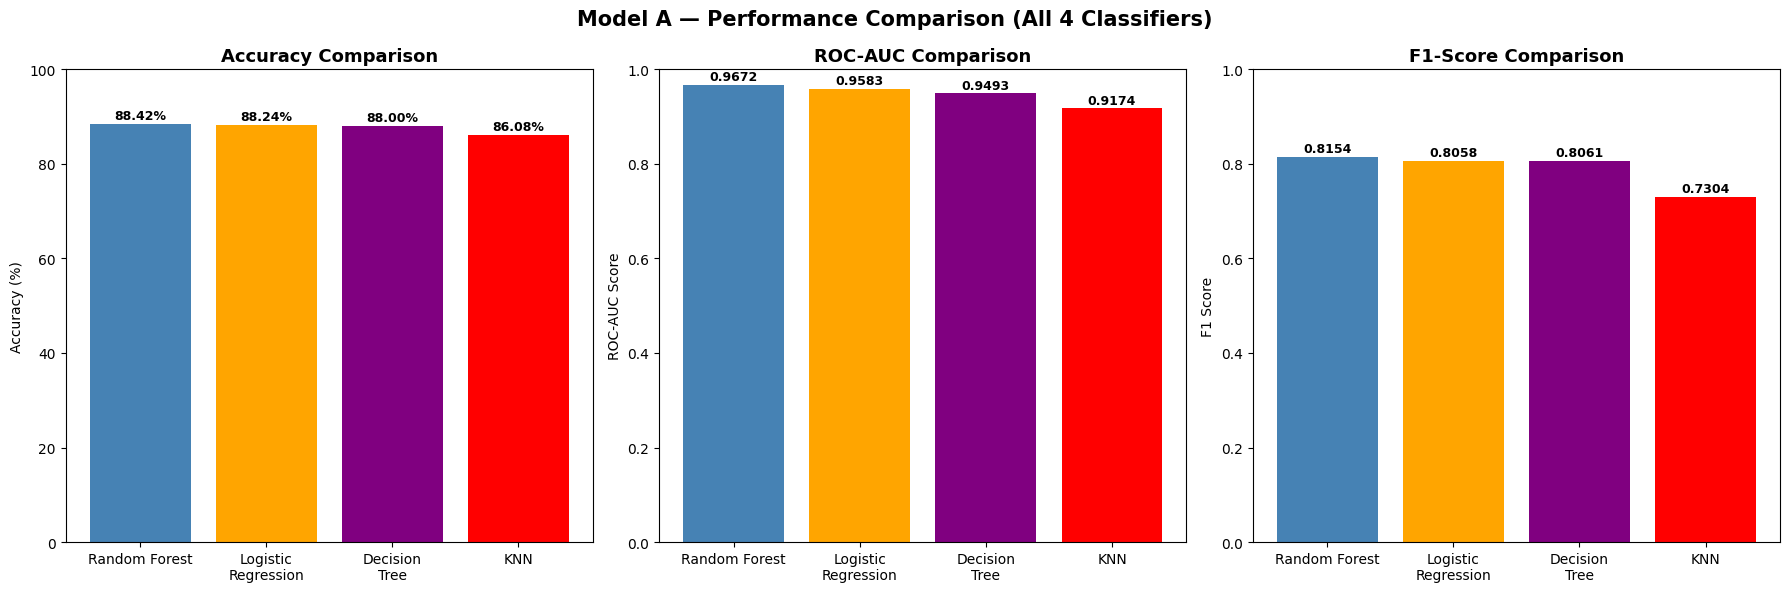

In [ ]:
# ============================================================
# STEP 6 — ACCURACY & ROC-AUC BAR CHART (Model A)
# ============================================================

all_models_A     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_A = [rf_acc_A*100, lr_acc_A2*100, dt_acc_A*100, knn_acc_A*100]
all_roc_aucs_A   = [rf_auc_A, lr_auc_A2, dt_auc_A, knn_auc_A]
all_f1s_A        = [f1_score(y_test_A, y_pred_rf_A),
                    f1_score(y_test_A, y_pred_lr_A2),
                    f1_score(y_test_A, y_pred_dt_A),
                    f1_score(y_test_A, y_pred_knn_A)]
all_prauc_A      = [rf_prauc_A, lr_prauc_A2, dt_prauc_A, knn_prauc_A]
all_colors_A     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].bar(all_models_A, all_accuracies_A, color=all_colors_A)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_A):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# ROC-AUC
axes[1].bar(all_models_A, all_roc_aucs_A, color=all_colors_A)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs_A):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# F1
axes[2].bar(all_models_A, all_f1s_A, color=all_colors_A)
axes[2].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0, 1])
for i, v in enumerate(all_f1s_A):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model A — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 7 — FEATURE IMPORTANCE (Model A — Random Forest)
# ============================================================

feature_importance_A = pd.DataFrame({
    'feature':    X_A_enc.columns,
    'importance': rf_A.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_A, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Random Forest (Model A)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feature_importance_A.head(10).to_string(index=False))


ValueError: All arrays must be of the same length

In [ ]:
# ============================================================
# STEP 8 — SUMMARY TABLE (Model A)
# ============================================================

summary_A = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_A],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs_A],
    'F1-Score':     [f"{v:.4f}" for v in all_f1s_A],
    'PR-AUC':       [f"{v:.4f}" for v in all_prauc_A],
})

print("\n🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 65)
print(summary_A.to_string(index=False))

best_acc_idx_A = all_accuracies_A.index(max(all_accuracies_A))
best_auc_idx_A = all_roc_aucs_A.index(max(all_roc_aucs_A))
best_f1_idx_A  = all_f1s_A.index(max(all_f1s_A))

print(f"\n🥇 Best by Accuracy : {summary_A['Model'][best_acc_idx_A]} ({max(all_accuracies_A):.2f}%)")
print(f"🥇 Best by ROC-AUC  : {summary_A['Model'][best_auc_idx_A]} ({max(all_roc_aucs_A):.4f})")
print(f"🥇 Best by F1-Score : {summary_A['Model'][best_f1_idx_A]} ({max(all_f1s_A):.4f})")



🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.42  0.9672   0.8154 0.9131
Logistic Regression        88.24  0.9583   0.8058 0.8743
      Decision Tree        88.00  0.9493   0.8061 0.8715
                KNN        86.08  0.9174   0.7304 0.7714

🥇 Best by Accuracy : Random Forest (88.42%)
🥇 Best by ROC-AUC  : Random Forest (0.9672)
🥇 Best by F1-Score : Random Forest (0.8154)


## MODEL B — MULTI-CLASS CLASSIFICATION (Delivery Status: delivered / delayed / failed)
### Using original delivery_status column — All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [ ]:
# ============================================================
# STEP 9 — TRAIN ALL 4 CLASSIFIERS (Model B: Multi-class)
# ============================================================

from sklearn.metrics import f1_score as f1

print(f"Model B Target: delivery_status (original column)")
print(f"Classes: {sorted(y_B.unique())}")
print(f"Class distribution:\n{y_B.value_counts()}\n")

# 1. Random Forest
print("🌲 Training Random Forest (Model B)...")
rf_B = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_B.fit(X_train_B_sc, y_train_B)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression (Model B)...")
lr_B2 = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_B2.fit(X_train_B_sc, y_train_B)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree (Model B)...")
dt_B = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_B.fit(X_train_B_sc, y_train_B)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN (Model B)...")
knn_B = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean'
)
knn_B.fit(X_train_B_sc, y_train_B)
print("✅ KNN done!")


Model B Target: delivery_status (original column)
Classes: ['delayed', 'delivered', 'failed']
Class distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

🌲 Training Random Forest (Model B)...
✅ Random Forest done!

📈 Training Logistic Regression (Model B)...
✅ Logistic Regression done!

🌳 Training Decision Tree (Model B)...
✅ Decision Tree done!

👥 Training KNN (Model B)...
✅ KNN done!


In [ ]:
# ============================================================
# STEP 10 — PREDICTIONS & EVALUATION (Model B)
# ============================================================

y_pred_rf_B   = rf_B.predict(X_test_B_sc)
y_pred_lr_B2  = lr_B2.predict(X_test_B_sc)
y_pred_dt_B   = dt_B.predict(X_test_B_sc)
y_pred_knn_B  = knn_B.predict(X_test_B_sc)

rf_acc_B   = accuracy_score(y_test_B, y_pred_rf_B)
lr_acc_B2  = accuracy_score(y_test_B, y_pred_lr_B2)
dt_acc_B   = accuracy_score(y_test_B, y_pred_dt_B)
knn_acc_B  = accuracy_score(y_test_B, y_pred_knn_B)

rf_f1_B    = f1(y_test_B, y_pred_rf_B,   average='macro')
lr_f1_B2   = f1(y_test_B, y_pred_lr_B2,  average='macro')
dt_f1_B    = f1(y_test_B, y_pred_dt_B,   average='macro')
knn_f1_B   = f1(y_test_B, y_pred_knn_B,  average='macro')

print("=" * 60)
print(" RANDOM FOREST — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {rf_acc_B*100:.2f}% | F1-macro: {rf_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_rf_B))

print("=" * 60)
print(" LOGISTIC REGRESSION — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {lr_acc_B2*100:.2f}% | F1-macro: {lr_f1_B2:.4f}")
print(classification_report(y_test_B, y_pred_lr_B2))

print("=" * 60)
print(" DECISION TREE — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {dt_acc_B*100:.2f}% | F1-macro: {dt_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_dt_B))

print("=" * 60)
print(" KNN — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {knn_acc_B*100:.2f}% | F1-macro: {knn_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_knn_B))


 RANDOM FOREST — Model B (Multi-class)
Accuracy: 81.68% | F1-macro: 0.5922
              precision    recall  f1-score   support

     delayed       0.58      0.84      0.68      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.18      0.18      0.18       266

    accuracy                           0.82      5000
   macro avg       0.58      0.62      0.59      5000
weighted avg       0.86      0.82      0.83      5000

 LOGISTIC REGRESSION — Model B (Multi-class)
Accuracy: 77.50% | F1-macro: 0.5630
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000

 DECISION TREE — Model B (Multi-class)
Accuracy: 75.34% | F1-macro: 0.5467
       

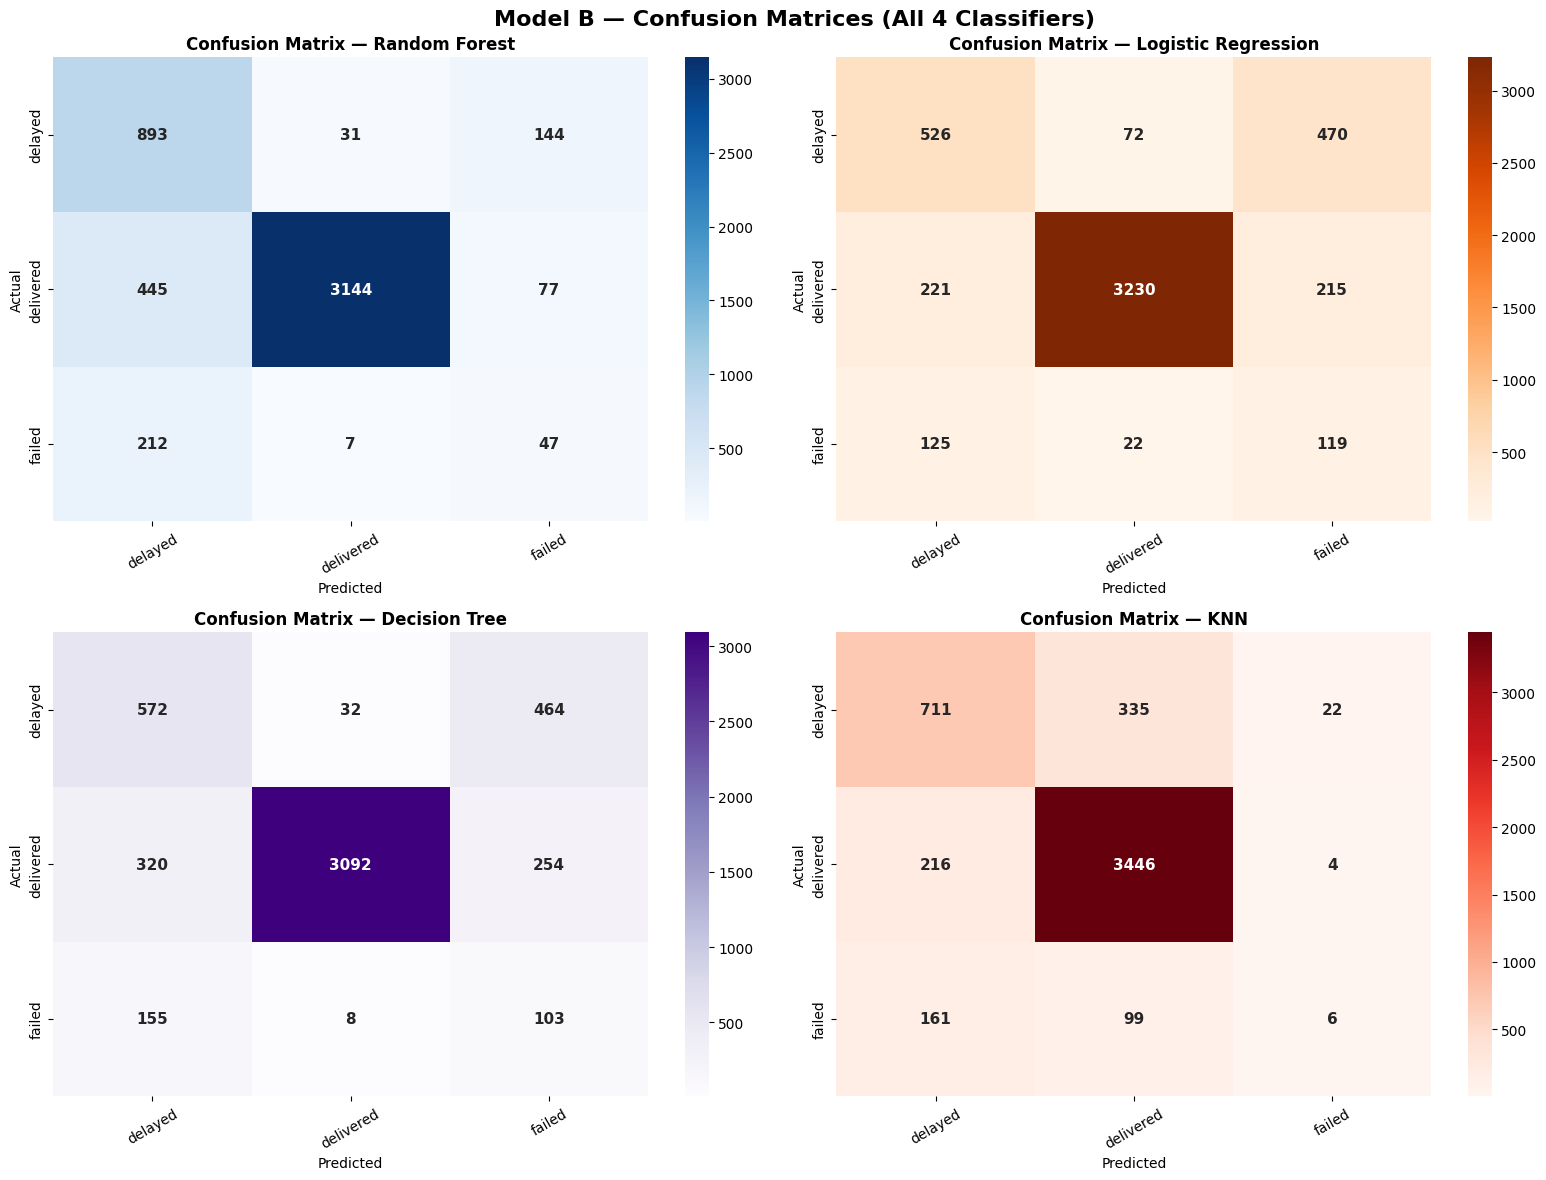

In [ ]:
# ============================================================
# STEP 11 — CONFUSION MATRICES: ALL 4 MODELS (Model B)
# ============================================================

class_labels_B = sorted(y_B.unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_B_info = [
    (y_pred_rf_B,  'Random Forest',       'Blues'),
    (y_pred_lr_B2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_B,  'Decision Tree',       'Purples'),
    (y_pred_knn_B, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_B_info):
    cm = confusion_matrix(y_test_B, y_pred, labels=class_labels_B)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=class_labels_B,
                yticklabels=class_labels_B,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model B — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


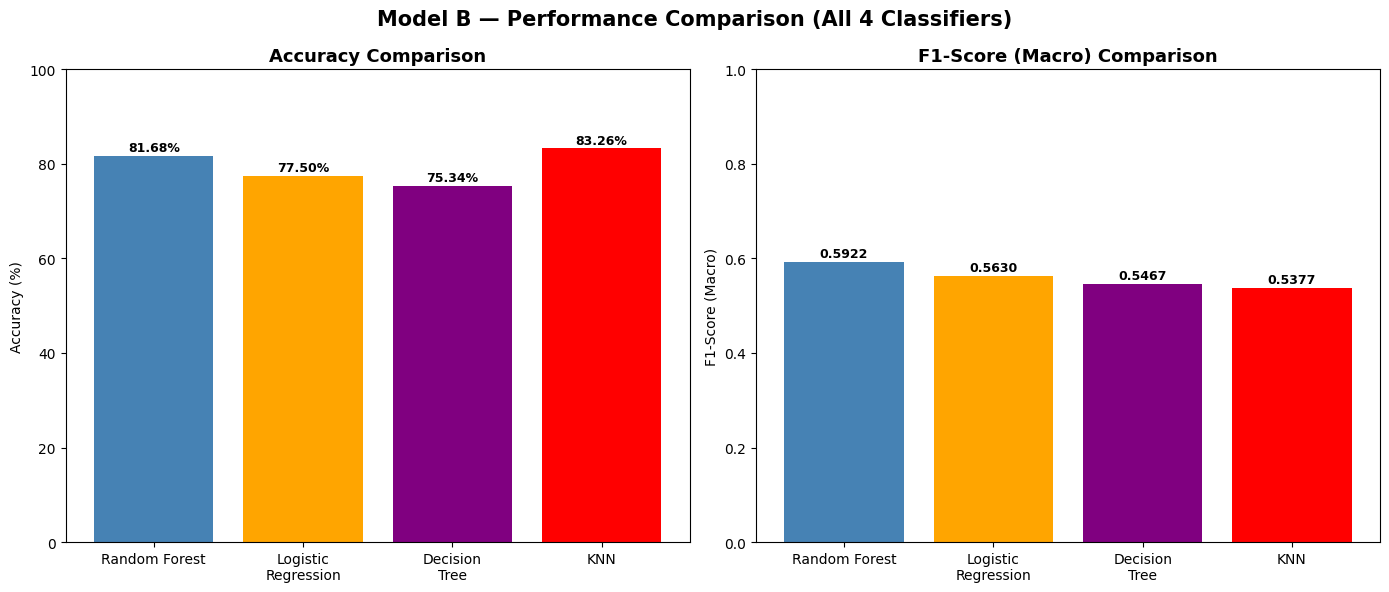

In [ ]:
# ============================================================
# STEP 12 — ACCURACY & F1 BAR CHART (Model B)
# ============================================================

all_models_B     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_B = [rf_acc_B*100, lr_acc_B2*100, dt_acc_B*100, knn_acc_B*100]
all_f1s_B        = [rf_f1_B, lr_f1_B2, dt_f1_B, knn_f1_B]
all_colors_B     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models_B, all_accuracies_B, color=all_colors_B)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_B):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models_B, all_f1s_B, color=all_colors_B)
axes[1].set_title('F1-Score (Macro) Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_f1s_B):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model B — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 13 — SUMMARY TABLE (Model B)
# ============================================================

summary_B = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_B],
    'F1-macro':     [f"{v:.4f}" for v in all_f1s_B],
})

print("MODEL B — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 55)
print(summary_B.to_string(index=False))

best_acc_idx_B = all_accuracies_B.index(max(all_accuracies_B))
best_f1_idx_B  = all_f1s_B.index(max(all_f1s_B))
print(f"Best by Accuracy : {summary_B['Model'][best_acc_idx_B]} ({max(all_accuracies_B):.2f}%)")
print(f" Best by F1-macro : {summary_B['Model'][best_f1_idx_B]} ({max(all_f1s_B):.4f})")



🏆 MODEL B — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) F1-macro
      Random Forest        98.52   0.8628
Logistic Regression        95.64   0.5879
      Decision Tree        99.08   0.8931
                KNN        97.28   0.4428
\ Best by Accuracy : Decision Tree (99.08%)
 Best by F1-macro : Decision Tree (0.8931)


## SAVE ALL MODELS

In [ ]:
# ============================================================
# STEP 14 — SAVE ALL 8 MODELS + ARTIFACTS
# ============================================================

# Model A — Binary Classification
with open('rf_A_model.pkl',  'wb') as f: pickle.dump(rf_A,        f)
with open('lr_A_model.pkl',  'wb') as f: pickle.dump(lr_A2,       f)
with open('dt_A_model.pkl',  'wb') as f: pickle.dump(dt_A,        f)
with open('knn_A_model.pkl', 'wb') as f: pickle.dump(knn_A,       f)

# Model B — Multi-class
with open('rf_B_model.pkl',  'wb') as f: pickle.dump(rf_B,        f)
with open('lr_B_model.pkl',  'wb') as f: pickle.dump(lr_B2,       f)
with open('dt_B_model.pkl',  'wb') as f: pickle.dump(dt_B,        f)
with open('knn_B_model.pkl', 'wb') as f: pickle.dump(knn_B,       f)

# Scalers & Encoders
with open('scaler_A.pkl',    'wb') as f: pickle.dump(scaler_A,    f)
with open('scaler_B.pkl',    'wb') as f: pickle.dump(scaler_B,    f)
with open('encoders_A.pkl',  'wb') as f: pickle.dump(encoders_A,  f)
with open('encoders_B.pkl',  'wb') as f: pickle.dump(encoders_B,  f)

print(" All models saved!")
print("\n  Model A (Binary Classification):")
print("   - rf_A_model.pkl   (Random Forest)")
print("   - lr_A_model.pkl   (Logistic Regression)")
print("   - dt_A_model.pkl   (Decision Tree)")
print("   - knn_A_model.pkl  (KNN)")
print("\n  Model B (Multi-class — Delay Severity):")
print("   - rf_B_model.pkl   (Random Forest)")
print("   - lr_B_model.pkl   (Logistic Regression)")
print("   - dt_B_model.pkl   (Decision Tree)")
print("   - knn_B_model.pkl  (KNN)")
print("\n  Preprocessing:")
print("   - scaler_A.pkl, scaler_B.pkl")
print("   - encoders_A.pkl, encoders_B.pkl")
